In [42]:
%pip install pandas

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\notefatec\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------- -------------------------- 3.4/9.7 MB 22.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 18.4 MB/s eta 0:00:00


In [20]:
import numpy as np
import matplotlib.pyplot as plt 
import csv 

In [21]:
# Função para carregar os dados d o CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1]), float(linha[2])]) # renda, idade, score
            y.append(int(linha[3]))
        return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("dataset_ex2.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primieras amostras:\n ", X[:5], "\nRótulos: ", y[:5])

Formato dos dados:  (22, 3) (22,)
Primieras amostras:
  [[ 2.  22.  45. ]
 [ 2.5 25.  50. ]
 [ 3.  28.  55. ]
 [ 4.  30.  60. ]
 [ 4.5 32.  62. ]] 
Rótulos:  [0 0 0 1 1]


In [22]:
def entropia(y):
    classes, contagem = np.unique(y, return_counts=True)
    probs = contagem / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

# Teste da entropia
print("Entropia [0, 0, 0, 0] -> ", entropia([0, 0, 0, 0]))
print("Entropia [0, 1, 0, 1] -> ", entropia([0, 1, 0, 1]))

Entropia [0, 0, 0, 0] ->  -1.4426951595367387e-09
Entropia [0, 1, 0, 1] ->  0.99999999711461


In [23]:
# ... (aqui estaria o código de carregar_dados que explicamos antes)

# 1. Você carrega os dados do arquivo
X, y = carregar_dados("dataset_ex1.csv")

# 2. Você chama a função de entropia passando o SEU 'y'
resultado = entropia(y)

print(f"A entropia real do meu dataset é: {resultado}")

A entropia real do meu dataset é: 0.9895875183366655


In [24]:
def dividir(X, y, feature, limiar):
    esquerda_idx = X[:, feature] <= limiar
    direita_idx = X[:, feature] > limiar
    return X[esquerda_idx], y[esquerda_idx], X[direita_idx], y[direita_idx]

# Testando renda mensal
Xe, ye, Xd, yd = dividir(X, y, feature=0, limiar=40)
print("Esquerda: ", ye)
print("Direita: ", yd)

Esquerda:  [0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1]
Direita:  [0 1 1 0 0 0 0 1 0]


In [25]:
class No:
    def __init__(self, feature=None, limiar=None, esquerda=None, direita=None, valor=None):
        self.feature = feature
        self.limiar = limiar
        self.esquerda = esquerda 
        self.direita = direita 
        self.valor = valor # classe se for folha 
    
class ArvoreDecisao:
    def __init__(self, max_profundidade=3, min_amostras=2):
        self.max_profundidade = max_profundidade
        self.min_amostras = min_amostras
        self.raiz = None 

    def ajustar(self, X, y):
        self.raiz = self._crescer(X, y, profundidade=0)

    def _crescer(self, X, y, profundidade):
        num_amostras, num_features = X.shape
        num_classes = len(np.unique(y))

        # Condições de parada
        if (profundidade >= self.max_profundidade or
            num_classes == 1 or
            num_amostras < self.min_amostras):
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        melhor_feature, melhor_limiar, melhor_info = None, None, -1
        melhor_divisao = None
        for feature in range(num_features):
            valores = np.unique(X[:, feature])
            for limiar in valores:
                X_esq, y_esq, X_dir, y_dir = dividir(X, y, feature, limiar)
                if len(y_esq) == 0 or len(y_dir) == 0:
                    continue

                ganho = entropia(y) - (
                    len(y_esq)/num_amostras * entropia(y_esq) + len(y_dir)/num_amostras * entropia(y_dir)
                )

                if ganho > melhor_info:
                    melhor_feature, melhor_limiar, melhor_info = feature, limiar, ganho
                    melhor_divisao = (X_esq, y_esq, X_dir, y_dir)

        if melhor_info == -1:
            classe_final = np.bincount(y).argmax()
            return No(valor=classe_final)

        esquerda = self._crescer(melhor_divisao[0], melhor_divisao[1], profundidade+1)
        direita = self._crescer(melhor_divisao[2], melhor_divisao[3], profundidade+1)
        return No(melhor_feature, melhor_limiar, esquerda, direita)

    def prever(self, X):
        return np.array([self._prever_amostra(x, self.raiz) for x in X])

    def _prever_amostra(self, x, no):
        if no.valor is not None:
            return no.valor
        if x[no.feature] <= no.limiar:
            return self._prever_amostra(x, no.esquerda)
        else:
            return self._prever_amostra(x, no.direita)

In [26]:
arvore = ArvoreDecisao(max_profundidade=3)
arvore.ajustar(X, y)

y_pred = arvore.prever(X)
acuracia = np.mean(y_pred == y)
print(f"Acurácia no conjunto de treino: {acuracia*100.:2f}%")

# Testando um cliente de 31 anos, 10 de exp, 5 treinamentos
novo_cliente = np.array([[4.0, 33, 76]])
print("Será promovido?", arvore.prever(novo_cliente))

Acurácia no conjunto de treino: 100.000000%
Será promovido? [0]


In [46]:
import pandas as pd

# 1. Carrega o arquivo
df = pd.read_csv('dataset_ex2.csv')

# 2. LIMPEZA CRUCIAL: Remove espaços extras de todas as colunas (ex: ' Renda' vira 'Renda')
df.columns = df.columns.str.strip()

# 3. Agora os nomes vão bater exatamente com o que você digitar
X = df[['Renda', 'Idade', 'Score']].values
y = df['Aprovado'].values

print("Colunas limpas com sucesso:", df.columns.tolist())

Colunas limpas com sucesso: ['Renda', 'Idade', 'Score', 'Aprovado']


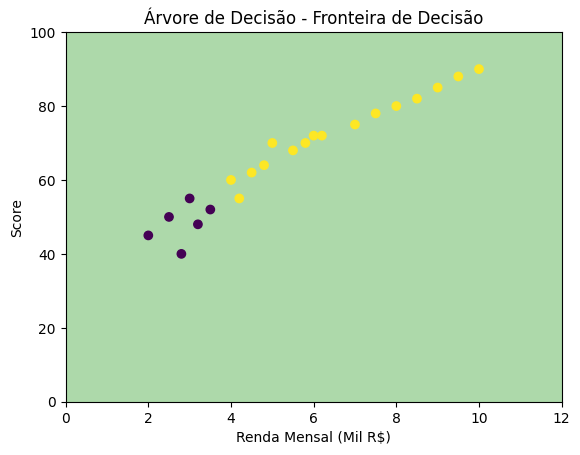

In [50]:
x_min, x_max = 0, 12
y_min, y_max = 0, 100

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                     np.linspace(y_min, y_max, 200))

idade_media = np.mean(X[:, 1])

Z = arvore.prever(np.c_[xx.ravel(), np.full(xx.ravel().shape, idade_media), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 2], c=y)#, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel("Renda Mensal (Mil R$)")
plt.ylabel("Score")
plt.title("Árvore de Decisão - Fronteira de Decisão")
plt.show()

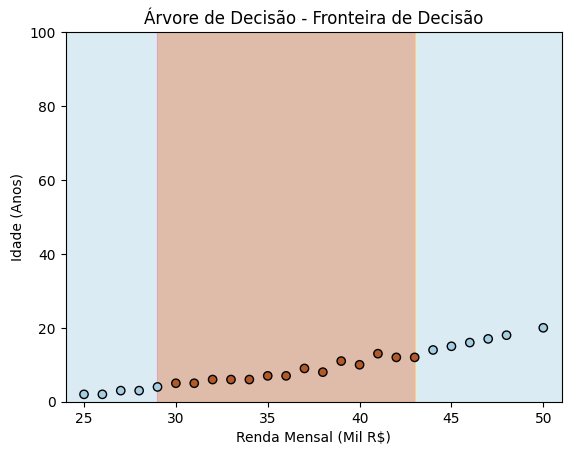

In [29]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-5, X[:, 1].max()+5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), 
                     np.linspace(y_min, y_max, 200))

Z = arvore.prever(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
plt.xlabel("Renda Mensal (Mil R$)")
plt.ylabel("Idade (Anos)")
plt.title("Árvore de Decisão - Fronteira de Decisão")
plt.show()

## a) Quais critérios foram mais determinantes para a aprovação de crédito: renda, idade ou score de crédito?

### Os citérios mais determinantes foram renda e score de crédito.

## b) Existe um limiar de score ou de renda a partir do qual o crédito quase sempre é aprovado?

### 